In [1]:
import constants as c
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

vk = c.vk
vrf = c.vrf
z0 = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
#eps = 1
alpha = 1/137.06
#m_dm = 2.873e-25
m_ion = c.m 
Z_charge = c.Z
freq_x = 719430.7131391969
freq_y = 3031200.0099101723
freq_z = 3002153.5607483205
omega = 2*pi*np.array([freq_x,freq_y,freq_z])
E_THRESHOLD = 1e-27

In [2]:
def make_area_weighted_b_list(b_max, n_b):
    u_edges = np.linspace(0.0, 1.0, n_b + 1)
    u_mid = 0.5 * (u_edges[:-1] + u_edges[1:])

    b_list = b_max * np.sqrt(u_mid)
    b_weights = np.diff(u_edges)

    return b_list, b_weights

In [3]:
def run_rutherford(m_dm, eps, speed_dm, plot=False, return_full=False, b_list=None, b_weights=None):
    ## 3. Simulate Rutherford scattering without the potential; use an ODE package to solve a coupled system
    # Initial condition for ion: rest and equilibrium
    x0_ion = [0,0,0]
    v0_ion = [0,0,0]

    r_trap = 1*cm
    if b_list is None or b_weights is None:
        b_list, b_weights = make_area_weighted_b_list(b_max=1e-3, n_b=100)
    #b_list = np.logspace(-5, -3, 100)  # 10 um to 1 mm

    E_threshold = 1e-27

    def fun2(t,U):
        x_ion = U[0:3]
        x_dm = U[3:6]
        v_ion = U[6:9]
        v_dm = U[9:12]
        E_trap = 0
        omega = 0
        delta_r = x_ion - x_dm
        dx_iondt = v_ion
        dv_iondt = -omega**2*x_ion + K*eps*e**2*delta_r/(m_ion*np.linalg.norm(delta_r)**3)
        dx_dmdt = v_dm
        dv_dmdt = -eps*e*E_trap/m_dm - K*eps*e**2*delta_r/(m_dm*np.linalg.norm(delta_r)**3)
        return np.concatenate([dx_iondt, dx_dmdt, dv_iondt, dv_dmdt])

    def scattering_angle_cm(sol):
        v1_ion, v2_ion, v3_ion = sol.y[6], sol.y[7], sol.y[8]
        v1_dm,  v2_dm,  v3_dm  = sol.y[9], sol.y[10], sol.y[11]

        v_rel0 = np.array([v1_dm[0] - v1_ion[0],
                           v2_dm[0] - v2_ion[0],
                           v3_dm[0] - v3_ion[0]])

        v_relF = np.array([v1_dm[-1] - v1_ion[-1],
                           v2_dm[-1] - v2_ion[-1],
                           v3_dm[-1] - v3_ion[-1]])

        cosθ = np.dot(v_relF, v_rel0) / (np.linalg.norm(v_relF)*np.linalg.norm(v_rel0))
        cosθ = np.clip(cosθ, -1, 1)
        return np.arccos(cosθ)

    def min_distance(sol):
        x1_ion, x2_ion, x3_ion = sol.y[0], sol.y[1], sol.y[2]
        x1_dm,  x2_dm,  x3_dm  = sol.y[3], sol.y[4], sol.y[5]
        r = np.sqrt((x1_ion-x1_dm)**2 + (x2_ion-x2_dm)**2 + (x3_ion-x3_dm)**2)
        return np.min(r)

    def energy_deposited_ion(sol):
        v1, v2, v3 = sol.y[6,-1], sol.y[7,-1], sol.y[8,-1]
        return 0.5 * m_ion * (v1**2 + v2**2 + v3**2)

    t_span = (0, 5e-3)
    t_eval = np.linspace(0, 5e-3, 20000)

    def run_one_event(r_trap, speed_dm, b):
        x0_dm = np.array([-r_trap, b, 0])
        v0_dm = np.array([speed_dm, 0, 0])

        U0 = np.concatenate([x0_ion, x0_dm, v0_ion, v0_dm])

        sol = solve_ivp(
            fun2,
            t_span,
            U0,
            method='DOP853',
            t_eval=t_eval,
            rtol=1e-10,
            atol=1e-12
        )
        return sol

    thetas = []
    rmins  = []
    Edeps  = []

    for b in b_list:
        sol = run_one_event(r_trap, speed_dm, b)

        thetas.append(scattering_angle_cm(sol))
        rmins.append(min_distance(sol))
        Edeps.append(energy_deposited_ion(sol))

    thetas = np.array(thetas)
    rmins  = np.array(rmins)
    Edeps  = np.array(Edeps)

    valid = Edeps >= E_threshold

    if np.any(valid):
        rmin_threshold = np.max(rmins[valid])
    else:
        rmin_threshold = np.nan

    if plot:
        plt.figure(figsize=(7,5))
        plt.plot(b_list*1e6, rmins*1e6, 'o-')
        plt.xlabel("Impact parameter b (um)")
        plt.ylabel("Minimum distance r_min (um)")
        plt.title("Closest Approach vs Impact Parameter")
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(7,5))
        plt.loglog(rmins*1e6, Edeps, 'o')
        plt.axhline(E_threshold, linestyle="--", label="Threshold")
        plt.xlabel("Minimum separation r_min (um)")
        plt.ylabel("Final ion energy / energy deposited (J)")
        plt.title("Ion Energy vs Minimum Distance")
        plt.legend()
        plt.grid(True, which='both')
        plt.show()

    q1 = e
    q2 = eps * e
    mu = (m_dm * m_ion) / (m_dm + m_ion)
    E  = 0.5 * mu * speed_dm**2
    C  = K*q1*q2

    b_nonzero = b_list.copy()
    b_nonzero[b_nonzero == 0] = np.nan
    thetas_analytic = 2*np.arctan(C/(2*E*b_nonzero))

    if plot:
        plt.figure(figsize=(8,6))
        plt.plot(b_list*1e6, thetas, 'bo', label="Simulation")
        plt.plot(b_list*1e6, thetas_analytic, 'r-', label="Analytic Rutherford")
        plt.xlabel("Impact parameter b (um)")
        plt.ylabel("Scattering angle theta (rad)")
        plt.title("Scattering Angle vs Impact Parameter")
        plt.legend()
        plt.grid(True)
        plt.show()

    if return_full:
        return {
            "rmin_threshold": rmin_threshold,
            "b_list": b_list,
            "b_weights": b_weights,
            "rmins": rmins,
            "Edeps": Edeps,
            "thetas": thetas,
            "speed_dm": speed_dm,
        }

    return rmin_threshold

In [4]:
def most_probable_speed_dm(T, m_dm):
    """
    Compute the most probable speed of a dark matter particle
    from the Maxwell-Boltzmann speed distribution.
    """
    k_B = 1.380649e-23  # J/K
    return np.sqrt(2 * k_B * T / m_dm)

def sample_MB_speed(T, m_dm, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    k_B = 1.380649e-23  # J/K

    sigma_v = np.sqrt(k_B * T / m_dm)

    vx = rng.normal(0.0, sigma_v)
    vy = rng.normal(0.0, sigma_v)
    vz = rng.normal(0.0, sigma_v)

    return np.sqrt(vx**2 + vy**2 + vz**2)

# One parameter point

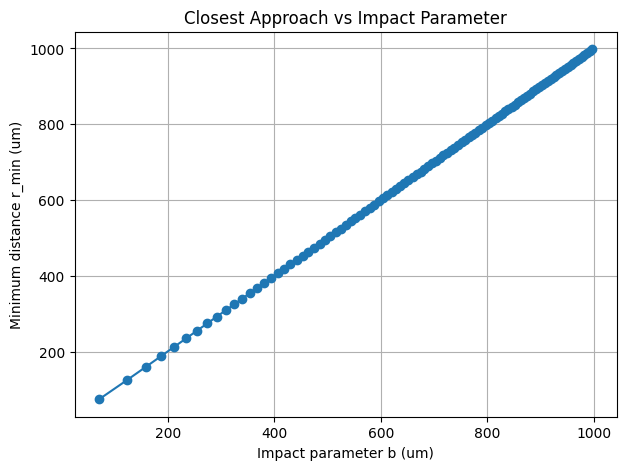

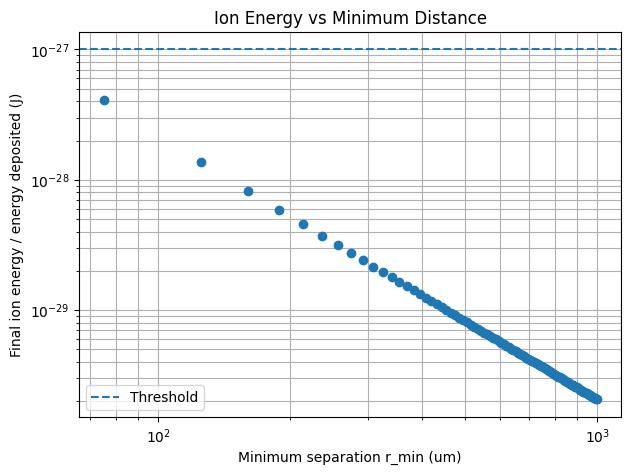

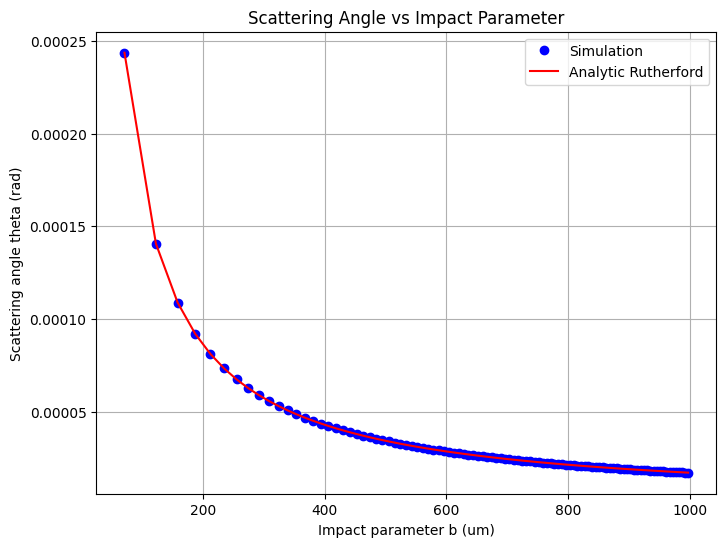

438.43359441000257
nan µm


In [5]:
T = 2000
m_dm = 2.873e-25
eps = 1
speed_dm = most_probable_speed_dm(T,m_dm)
rmin_cutoff = run_rutherford(m_dm, eps, speed_dm, plot=True)
print(speed_dm)
print(rmin_cutoff * 1e6, "µm")

# Many parameter points

done: m_dm = 1.000e-26 kg, eps = 1.000e-02, <speed> = 1018.201 m/s, P(E >= Eth) = 0.000e+00, r_min_threshold = nan um, E_median = 9.837e-35 J
done: m_dm = 1.000e-26 kg, eps = 1.438e-02, <speed> = 1018.201 m/s, P(E >= Eth) = 0.000e+00, r_min_threshold = nan um, E_median = 2.035e-34 J
done: m_dm = 1.000e-26 kg, eps = 2.069e-02, <speed> = 1018.201 m/s, P(E >= Eth) = 0.000e+00, r_min_threshold = nan um, E_median = 4.211e-34 J
done: m_dm = 1.000e-26 kg, eps = 2.976e-02, <speed> = 1018.201 m/s, P(E >= Eth) = 0.000e+00, r_min_threshold = nan um, E_median = 8.714e-34 J
done: m_dm = 1.000e-26 kg, eps = 4.281e-02, <speed> = 1018.201 m/s, P(E >= Eth) = 0.000e+00, r_min_threshold = nan um, E_median = 1.803e-33 J
done: m_dm = 1.000e-26 kg, eps = 6.158e-02, <speed> = 1018.201 m/s, P(E >= Eth) = 0.000e+00, r_min_threshold = nan um, E_median = 3.731e-33 J
done: m_dm = 1.000e-26 kg, eps = 8.859e-02, <speed> = 1018.201 m/s, P(E >= Eth) = 0.000e+00, r_min_threshold = nan um, E_median = 7.720e-33 J
done: 

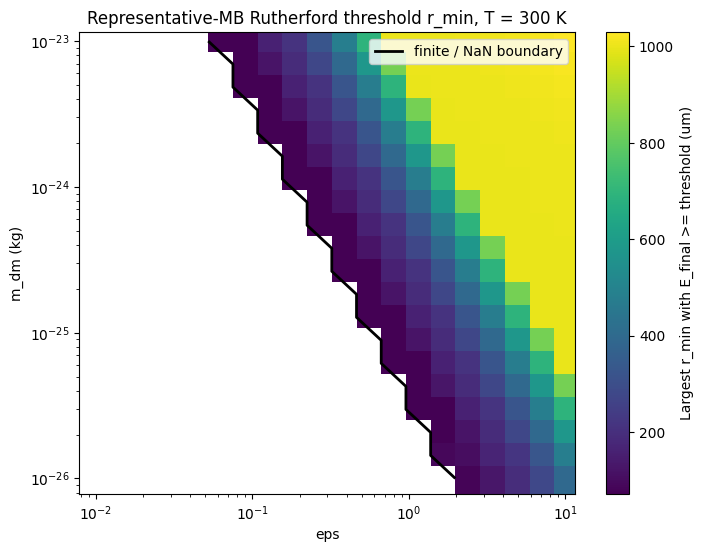

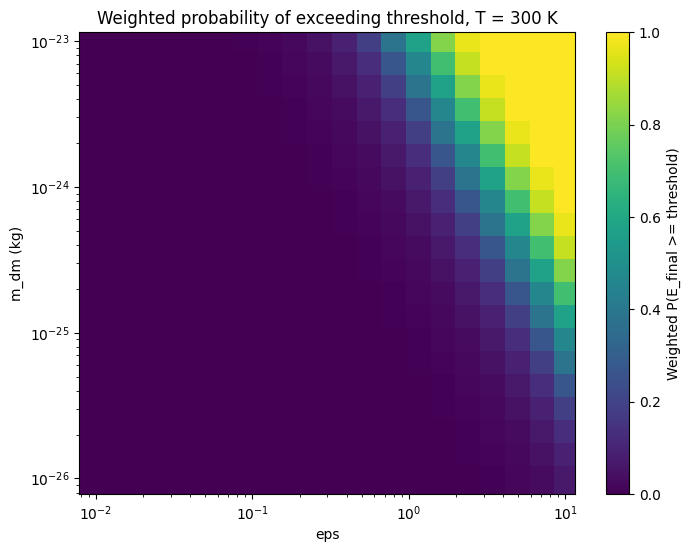

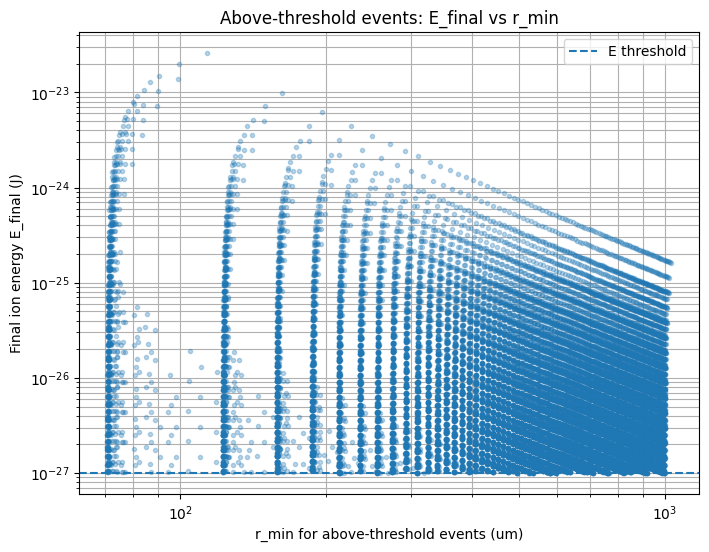

In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.stats import maxwell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Temperature for Maxwell-Boltzmann speed
T_dm = 300  # K
E_threshold = 1e-27

# Parameter scan
m_dm_values = np.logspace(-26, -23, 20)
eps_values = np.logspace(-2, 1, 20)

# Representative MB speeds per (m_dm, eps)
n_speed_samples = 5

# Area-weighted impact parameter samples
b_max = 1e-3   # 1 mm
n_b = 100

b_list, b_weights = make_area_weighted_b_list(
    b_max=b_max,
    n_b=n_b
)

# Number of threads
n_threads = 8


def deterministic_MB_speeds(T, m_dm, n_speeds=5):
    k_B = 1.380649e-23  # J/K

    scale = np.sqrt(k_B * T / m_dm)

    # Midpoints of equal-probability bins
    quantiles = (np.arange(n_speeds) + 0.5) / n_speeds

    speeds = maxwell.ppf(quantiles, scale=scale)

    # Each representative speed corresponds to the same probability mass
    speed_weights = np.full(n_speeds, 1.0 / n_speeds)

    return speeds, speed_weights


def run_one_parameter_point(i, j, m_dm, eps):
    speed_samples, speed_weights = deterministic_MB_speeds(
        T_dm,
        m_dm,
        n_speeds=n_speed_samples
    )

    E_samples_all = []
    rmin_samples_all = []
    weights_all = []

    rmin_threshold_per_speed = []
    prob_per_speed = []
    speed_detected = []

    for speed_dm, speed_weight in zip(speed_samples, speed_weights):

        out = run_rutherford(
            m_dm=m_dm,
            eps=eps,
            speed_dm=speed_dm,
            plot=False,
            return_full=True,
            b_list=b_list,
            b_weights=b_weights
        )

        Edeps = np.array(out["Edeps"])
        rmins = np.array(out["rmins"])
        this_b_weights = np.array(out["b_weights"])

        valid_this_speed = Edeps >= E_threshold

        # Probability over impact parameter for this speed
        prob_this_speed = np.sum(this_b_weights[valid_this_speed])
        prob_per_speed.append(prob_this_speed)

        if np.any(valid_this_speed):
            rmin_this_speed = np.max(rmins[valid_this_speed])
            detected_this_speed = True
        else:
            rmin_this_speed = np.nan
            detected_this_speed = False

        rmin_threshold_per_speed.append(rmin_this_speed)
        speed_detected.append(detected_this_speed)

        E_samples_all.extend(Edeps)
        rmin_samples_all.extend(rmins)

        # Weight for each trajectory = speed weight times b-bin weight
        weights_all.extend(speed_weight * this_b_weights)

    E_samples_all = np.array(E_samples_all)
    rmin_samples_all = np.array(rmin_samples_all)
    weights_all = np.array(weights_all)

    speed_samples = np.array(speed_samples)
    speed_weights = np.array(speed_weights)

    rmin_threshold_per_speed = np.array(rmin_threshold_per_speed)
    prob_per_speed = np.array(prob_per_speed)
    speed_detected = np.array(speed_detected)

    valid = E_samples_all >= E_threshold

    # Weighted probability over speed and impact parameter
    prob_above_threshold = np.sum(weights_all[valid]) / np.sum(weights_all)

    # Probability that a representative speed has any detectable b value
    prob_speed_has_any_above_threshold = np.sum(speed_weights[speed_detected])

    if np.any(valid):
        rmin_threshold = np.max(rmin_samples_all[valid])
        rmin_valid_mean = np.average(rmin_samples_all[valid], weights=weights_all[valid])
        rmin_valid_median = np.median(rmin_samples_all[valid])

        valid_rmins = rmin_samples_all[valid]
        valid_Edeps = E_samples_all[valid]
    else:
        rmin_threshold = np.nan
        rmin_valid_mean = np.nan
        rmin_valid_median = np.nan

        valid_rmins = np.array([])
        valid_Edeps = np.array([])

    if np.any(np.isfinite(rmin_threshold_per_speed)):
        rmin_threshold_mean_over_speeds = np.nanmean(rmin_threshold_per_speed)
        rmin_threshold_median_over_speeds = np.nanmedian(rmin_threshold_per_speed)
        rmin_threshold_max_over_speeds = np.nanmax(rmin_threshold_per_speed)
    else:
        rmin_threshold_mean_over_speeds = np.nan
        rmin_threshold_median_over_speeds = np.nan
        rmin_threshold_max_over_speeds = np.nan

    row = {
        "m_dm_kg": m_dm,
        "eps": eps,
        "n_speed_representatives": n_speed_samples,
        "n_b_samples": n_b,
        "n_total_events": len(E_samples_all),

        "speed_mean_m_s": np.sum(speed_samples * speed_weights),
        "speed_min_m_s": np.min(speed_samples),
        "speed_median_rep_m_s": speed_samples[n_speed_samples // 2],
        "speed_max_m_s": np.max(speed_samples),

        "E_final_weighted_mean_J": np.average(E_samples_all, weights=weights_all),
        "E_final_median_J": np.median(E_samples_all),
        "E_final_p05_J": np.percentile(E_samples_all, 5),
        "E_final_p25_J": np.percentile(E_samples_all, 25),
        "E_final_p75_J": np.percentile(E_samples_all, 75),
        "E_final_p95_J": np.percentile(E_samples_all, 95),
        "E_final_max_J": np.max(E_samples_all),

        "prob_E_above_threshold": prob_above_threshold,
        "prob_speed_has_any_above_threshold": prob_speed_has_any_above_threshold,

        "r_min_threshold_m": rmin_threshold,
        "r_min_threshold_um": rmin_threshold * 1e6 if np.isfinite(rmin_threshold) else np.nan,

        "r_min_valid_weighted_mean_um": rmin_valid_mean * 1e6 if np.isfinite(rmin_valid_mean) else np.nan,
        "r_min_valid_median_um": rmin_valid_median * 1e6 if np.isfinite(rmin_valid_median) else np.nan,

        "r_min_threshold_mean_over_speeds_um": (
            rmin_threshold_mean_over_speeds * 1e6
            if np.isfinite(rmin_threshold_mean_over_speeds)
            else np.nan
        ),
        "r_min_threshold_median_over_speeds_um": (
            rmin_threshold_median_over_speeds * 1e6
            if np.isfinite(rmin_threshold_median_over_speeds)
            else np.nan
        ),
        "r_min_threshold_max_over_speeds_um": (
            rmin_threshold_max_over_speeds * 1e6
            if np.isfinite(rmin_threshold_max_over_speeds)
            else np.nan
        ),
    }

    return {
        "i": i,
        "j": j,
        "row": row,
        "rmin_threshold": rmin_threshold,
        "prob_above_threshold": prob_above_threshold,
        "E_median": np.median(E_samples_all),
        "E_mean": np.average(E_samples_all, weights=weights_all),
        "speed_mean": np.sum(speed_samples * speed_weights),
        "valid_rmins": valid_rmins,
        "valid_Edeps": valid_Edeps,
        "valid_mdm": np.full(len(valid_rmins), m_dm),
        "valid_eps": np.full(len(valid_rmins), eps),
    }


# Output grids
rmin_grid = np.full((len(m_dm_values), len(eps_values)), np.nan)
prob_grid = np.full((len(m_dm_values), len(eps_values)), np.nan)
E_median_grid = np.full((len(m_dm_values), len(eps_values)), np.nan)
E_mean_grid = np.full((len(m_dm_values), len(eps_values)), np.nan)
speed_mean_grid = np.full((len(m_dm_values), len(eps_values)), np.nan)

results = []

all_valid_rmins_list = []
all_valid_Edeps_list = []
all_valid_mdm_list = []
all_valid_eps_list = []

# Build task list
tasks = []

for i, m_dm in enumerate(m_dm_values):
    for j, eps in enumerate(eps_values):
        tasks.append((i, j, m_dm, eps))


# Run in parallel
with ThreadPoolExecutor(max_workers=n_threads) as executor:
    futures = [
        executor.submit(run_one_parameter_point, i, j, m_dm, eps)
        for i, j, m_dm, eps in tasks
    ]

    for future in as_completed(futures):
        out = future.result()

        i = out["i"]
        j = out["j"]
        row = out["row"]

        rmin_grid[i, j] = out["rmin_threshold"]
        prob_grid[i, j] = out["prob_above_threshold"]
        E_median_grid[i, j] = out["E_median"]
        E_mean_grid[i, j] = out["E_mean"]
        speed_mean_grid[i, j] = out["speed_mean"]

        results.append(row)

        if len(out["valid_rmins"]) > 0:
            all_valid_rmins_list.append(out["valid_rmins"])
            all_valid_Edeps_list.append(out["valid_Edeps"])
            all_valid_mdm_list.append(out["valid_mdm"])
            all_valid_eps_list.append(out["valid_eps"])

        print(
            f"done: m_dm = {row['m_dm_kg']:.3e} kg, "
            f"eps = {row['eps']:.3e}, "
            f"<speed> = {row['speed_mean_m_s']:.3f} m/s, "
            f"P(E >= Eth) = {row['prob_E_above_threshold']:.3e}, "
            f"r_min_threshold = {row['r_min_threshold_um']:.3f} um, "
            f"E_median = {row['E_final_median_J']:.3e} J"
        )


# Convert lists to arrays
if len(all_valid_rmins_list) > 0:
    all_valid_rmins = np.concatenate(all_valid_rmins_list)
    all_valid_Edeps = np.concatenate(all_valid_Edeps_list)
    all_valid_mdm = np.concatenate(all_valid_mdm_list)
    all_valid_eps = np.concatenate(all_valid_eps_list)
else:
    all_valid_rmins = np.array([])
    all_valid_Edeps = np.array([])
    all_valid_mdm = np.array([])
    all_valid_eps = np.array([])


# Make dataframe
results_df = pd.DataFrame(results)

# Sort so the printed table is ordered by m_dm, eps
results_df = results_df.sort_values(["m_dm_kg", "eps"]).reset_index(drop=True)

print(
    results_df.to_string(
        index=False,
        formatters={
            "m_dm_kg": "{:.3e}".format,
            "eps": "{:.3e}".format,

            "speed_mean_m_s": "{:.3f}".format,
            "speed_min_m_s": "{:.3f}".format,
            "speed_median_rep_m_s": "{:.3f}".format,
            "speed_max_m_s": "{:.3f}".format,

            "E_final_weighted_mean_J": "{:.3e}".format,
            "E_final_median_J": "{:.3e}".format,
            "E_final_p05_J": "{:.3e}".format,
            "E_final_p25_J": "{:.3e}".format,
            "E_final_p75_J": "{:.3e}".format,
            "E_final_p95_J": "{:.3e}".format,
            "E_final_max_J": "{:.3e}".format,

            "prob_E_above_threshold": "{:.3e}".format,
            "prob_speed_has_any_above_threshold": "{:.3f}".format,

            "r_min_threshold_m": "{:.3e}".format,
            "r_min_threshold_um": "{:.3f}".format,
            "r_min_valid_weighted_mean_um": "{:.3f}".format,
            "r_min_valid_median_um": "{:.3f}".format,
            "r_min_threshold_mean_over_speeds_um": "{:.3f}".format,
            "r_min_threshold_median_over_speeds_um": "{:.3f}".format,
            "r_min_threshold_max_over_speeds_um": "{:.3f}".format,
        }
    )
)

EPS, M = np.meshgrid(eps_values, m_dm_values)

plt.figure(figsize=(8, 6))

plt.pcolormesh(
    EPS,
    M,
    rmin_grid * 1e6,
    shading="auto"
)

plt.xscale("log")
plt.yscale("log")
plt.colorbar(label="Largest r_min with E_final >= threshold (um)")
plt.xlabel("eps")
plt.ylabel("m_dm (kg)")
plt.title(f"Representative-MB Rutherford threshold r_min, T = {T_dm} K")

valid_mask = np.isfinite(rmin_grid)

if np.any(valid_mask) and np.any(~valid_mask):
    plt.contour(
        EPS,
        M,
        valid_mask.astype(float),
        levels=[0.5],
        colors="black",
        linewidths=2
    )

    boundary_line = Line2D(
        [0],
        [0],
        color="black",
        linewidth=2,
        label="finite / NaN boundary"
    )

    plt.legend(handles=[boundary_line])

plt.show()


plt.figure(figsize=(8, 6))

plt.pcolormesh(
    EPS,
    M,
    prob_grid,
    shading="auto",
    vmin=0,
    vmax=1
)

plt.xscale("log")
plt.yscale("log")
plt.colorbar(label="Weighted P(E_final >= threshold)")
plt.xlabel("eps")
plt.ylabel("m_dm (kg)")
plt.title(f"Weighted probability of exceeding threshold, T = {T_dm} K")
plt.show()


plt.figure(figsize=(8, 6))

plt.loglog(
    all_valid_rmins * 1e6,
    all_valid_Edeps,
    ".",
    alpha=0.3
)

plt.axhline(E_threshold, linestyle="--", label="E threshold")

plt.xlabel("r_min for above-threshold events (um)")
plt.ylabel("Final ion energy E_final (J)")
plt.title("Above-threshold events: E_final vs r_min")
plt.legend()
plt.grid(True, which="both")
plt.show()

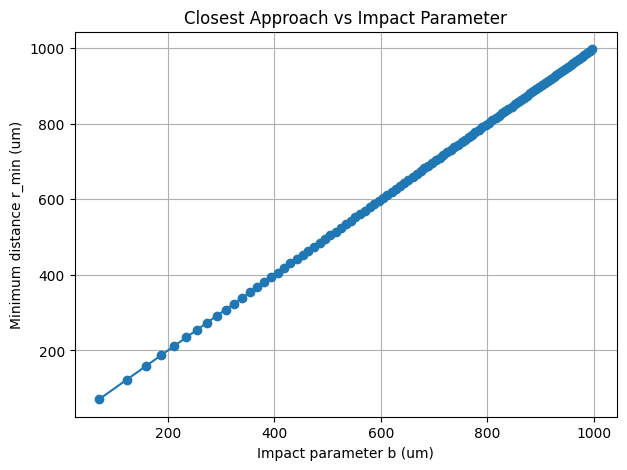

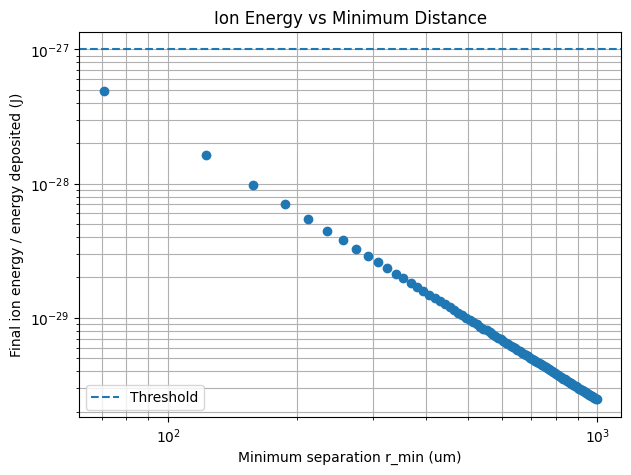

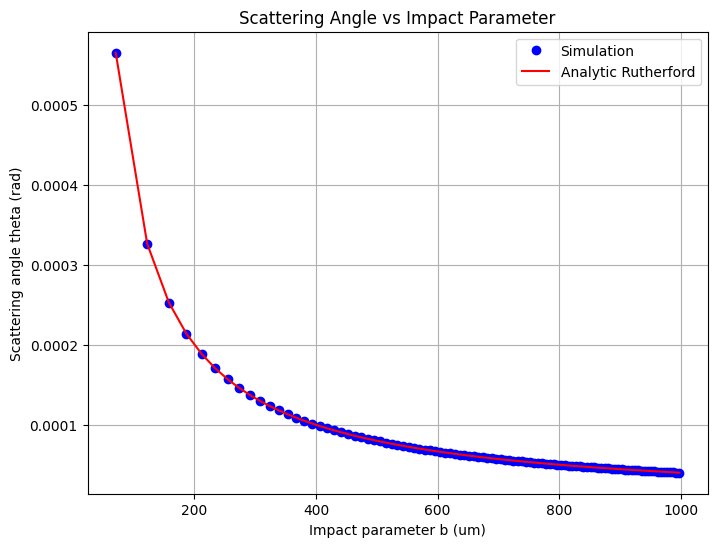

Custom Rutherford point:
m_dm  = 1.000e-25 kg
eps   = 1.000e+00
speed = 400.000000 m/s
r_min = nan


In [ ]:
def evaluate_custom_point(m_dm_custom, eps_custom, speed_custom,T_dm=300, plot=False):
    #speed_custom = most_probable_speed_dm(T_dm, m_dm_custom)

    rmin_custom = run_rutherford(
        m_dm=m_dm_custom,
        eps=eps_custom,
        speed_dm=speed_custom,
        plot=plot
    )

    print("Custom Rutherford point:")
    print(f"m_dm  = {m_dm_custom:.3e} kg")
    print(f"eps   = {eps_custom:.3e}")
    print(f"speed = {speed_custom:.6f} m/s")

    if np.isfinite(rmin_custom):
        print(f"r_min = {rmin_custom:.3e} m = {rmin_custom * 1e6:.3f} um")
    else:
        print("r_min = nan")

    return {
        "m_dm_kg": m_dm_custom,
        "eps": eps_custom,
        "speed_dm_m_s": speed_custom,
        "r_min_threshold_m": rmin_custom,
        "r_min_threshold_um": rmin_custom * 1e6 if np.isfinite(rmin_custom) else np.nan
    }

m_dm_custom = 2.637e-25  #float(input("Enter m_dm in kg: "))
eps_custom = 2.336e+00 #float(input("Enter eps: "))
speed_custom = 273.176403

custom_result = evaluate_custom_point(
    m_dm_custom=m_dm_custom,
    eps_custom=eps_custom,
    speed_custom=speed_custom,
    plot=True
)